### Import Dependencies

In [1]:
import json
import gzip
import pandas as pd
import requests

### Working with downloaded data

In [5]:
file_path = "/Users/bentonturner/Downloads/meta_CDs_and_Vinyl.jsonl.gz"

with gzip.open(file_path, "rt") as f:
    first_line = json.loads(f.readline())

In [4]:
first_line

{'main_category': 'Digital Music',
 'title': 'Release Some Tension',
 'average_rating': 4.6,
 'rating_number': 112,
 'features': [],
 'description': ['Swv ~ Release Some Tension'],
 'price': 12.05,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/517h9OROQAL._SS40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/517h9OROQAL.jpg',
   'variant': 'MAIN',
   'hi_res': 'https://m.media-amazon.com/images/I/71VRDLrTvYL._SL1500_.jpg'}],
 'videos': [],
 'store': 'SWV   Format: Audio CD',
 'categories': ['CDs & Vinyl', 'Dance & Electronic', 'House'],
 'details': {'Is Discontinued By Manufacturer': 'No',
  'Product Dimensions': '5.62 x 4.92 x 0.33 inches; 3.84 Ounces',
  'Manufacturer': 'Sony Legacy',
  'Item model number': '2013033',
  'Original Release Date': '1997',
  'Run time': '53 minutes',
  'Date First Available': 'December 7, 2006',
  'Label': 'Sony Legacy',
  'Number of discs': '1'},
 'parent_asin': 'B000002X4C',
 'bought_together': None}

### Filter out only recent items (apeared in stock in 2022 or 2023)

In [6]:
def filter_data_by_date(data: dict) -> bool:
    filter = False
    if int(data["details"]["Date First Available"][-4:]) < 2022:
        filter = True

    return filter

In [7]:
test_dict = {'main_category': 'Digital Music',
 'title': 'Release Some Tension',
 'average_rating': 4.6,
 'rating_number': 112,
 'features': [],
 'description': ['Swv ~ Release Some Tension'],
 'price': 12.05,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/517h9OROQAL._SS40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/517h9OROQAL.jpg',
   'variant': 'MAIN',
   'hi_res': 'https://m.media-amazon.com/images/I/71VRDLrTvYL._SL1500_.jpg'}],
 'videos': [],
 'store': 'SWV   Format: Audio CD',
 'categories': ['CDs & Vinyl', 'Dance & Electronic', 'House'],
 'details': {'Is Discontinued By Manufacturer': 'No',
  'Product Dimensions': '5.62 x 4.92 x 0.33 inches; 3.84 Ounces',
  'Manufacturer': 'Sony Legacy',
  'Item model number': '2013033',
  'Original Release Date': '1997',
  'Run time': '53 minutes',
  'Date First Available': 'December 7, 2006',
  'Label': 'Sony Legacy',
  'Number of discs': '1'},
 'parent_asin': 'B000002X4C',
 'bought_together': None}

In [ ]:
filter_data_by_date(test_dict)

True

In [18]:
input_path = "../../data/meta_CDs_and_Vinyl.jsonl.gz"
output_dir = "../../data"
with gzip.open(input_path, "rt") as fp:
    with open(f"{output_dir}/meta_CDs_and_Vinyl_2022_2023.jsonl", "a", encoding="utf-8") as fp_out:
        with open(f"{output_dir}/meta_CDs_and_Vinyl_2022_2023_no_date.jsonl", "a", encoding="utf-8") as fp_out_no_date:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data_by_date(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write("\n")
                        fp_out.flush()
                except:
                    json.dump(data, fp_out_no_date)
                    fp_out_no_date.write("\n")
                    fp_out_no_date.flush()
                i += 1
                if i % 10000 == 0:
                    print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines
Processed 190000 lines
Processed 200000 lines
Processed 210000 lines
Processed 220000 lines
Processed 230000 lines
Processed 240000 lines
Processed 250000 lines
Processed 260000 lines
Processed 270000 lines
Processed 280000 lines
Processed 290000 lines
Processed 300000 lines
Processed 310000 lines
Processed 320000 lines
Processed 330000 lines
Processed 340000 lines
Processed 350000 lines
Processed 360000 lines
Processed 370000 lines
Processed 380000 lines
Processed 390000 lines
Processed 400000 lines
Processed 410000 lines
Processed 420000 lines
Processed 430000 lines
Processed 440000 lin

### Split the items into two categroties: "has main category", "does not have main category"

In [19]:
def filter_category(data: dict) -> dict:
    filter = False
    if data['main_category'] == None:
        filter = True

    return filter

In [21]:
with open("../../data/meta_CDs_and_Vinyl_2022_2023.jsonl", "r") as fp:
    with open("../../data/meta_CDs_and_Vinyl_2022_2023_with_category.jsonl", "a", encoding="utf-8") as fp_out:
        with open("../../data/meta_CDs_and_Vinyl_2022_2023_no_category.jsonl", "a", encoding="utf-8") as fp_out_no_category:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                if not filter_category(data):
                    json.dump(data, fp_out)
                    fp_out.write("\n")
                    fp_out.flush()
                else:
                    json.dump(data, fp_out_no_category)
                    fp_out_no_category.write("\n")
                    fp_out_no_category.flush()
                i += 1
                if i % 10000 == 0:
                    print(f"Processed {i} lines")

### Explore distribution by categories

In [22]:
df = pd.read_json("../../data/meta_CDs_and_Vinyl_2022_2023_with_category.jsonl", lines=True)

In [23]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Digital Music,Cracker Black,4.7,90,[],[Limited 180gm black vinyl LP pressing. Cracke...,25.00,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cracker Format: Vinyl,"[CDs & Vinyl, Rock]",{'Product Dimensions': '12.5 x 12.5 x 0.13 inc...,B09X7MMY8Z,NaN
1,Digital Music,I NEVER LIKED YOU Explicit Lyrics,4.8,171,[],[EPIC RECORDS FUTURE - I NEVER LIKED YOU - Fut...,12.98,[{'thumb': 'https://m.media-amazon.com/images/...,[],Future Format: Audio CD,"[CDs & Vinyl, Rap & Hip-Hop]","{'Language': 'Japanese', 'Product Dimensions':...",B09Z6X7V1N,NaN
2,Digital Music,Terror Twilight: Farewell Horizontal,4.7,102,[],[Matador’s complete series of expanded edition...,16.94,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pavement Format: Audio CD,"[CDs & Vinyl, Indie & Alternative, Alternative...","{'Language': 'English', 'Product Dimensions': ...",B09PK44XXK,NaN
3,Digital Music,C’MON YOU KNOW (Amazon Ocean Blue,4.7,399,[],[],28.63,[{'thumb': 'https://m.media-amazon.com/images/...,[],Liam Gallagher Format: Vinyl,"[CDs & Vinyl, Rock]","{'Language': 'English', 'Product Dimensions': ...",B09QQT2TM7,NaN
4,Digital Music,Radio Transient,5.0,1,[],"[2023 release from celebrated Lenoir, North Ca...",11.98,[{'thumb': 'https://m.media-amazon.com/images/...,[],Chris Church (Artist) Format: Audio CD,"[CDs & Vinyl, Rock]",{'Product Dimensions': '4.9 x 5.5 x 0.25 inche...,B0BS464JWJ,NaN


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='main_category'>

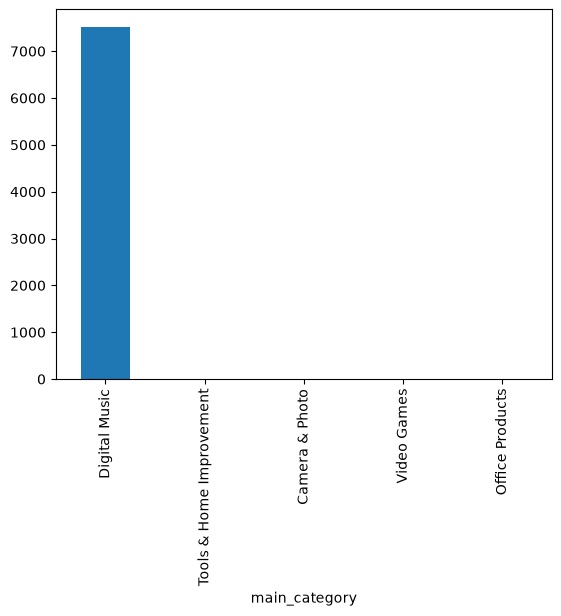

In [24]:
df["main_category"].value_counts().plot(kind="bar")

### Filter out items that have at least 100 ratigs

In [25]:
df_ratings_100 = df[df["rating_number"] >= 100]

In [26]:
len(df)

7521

In [ ]:
len(df_ratings_100)

<Axes: xlabel='main_category'>

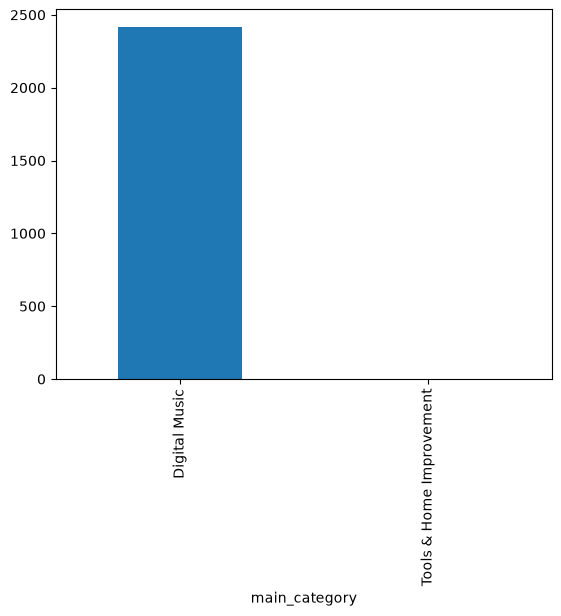

In [27]:
df_ratings_100["main_category"].value_counts().plot(kind="bar")

### Explore Distribution of ratings

<Axes: ylabel='Frequency'>

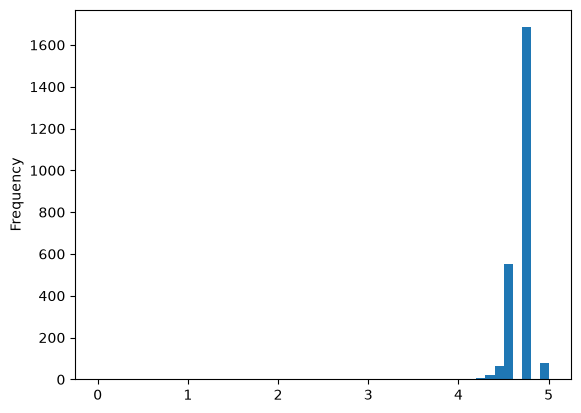

In [28]:
df_ratings_100["average_rating"].plot(kind="hist", bins=50, range=(0, 5))

### Sample 1000

In [30]:
df_sample_1000 = df_ratings_100.sample(n=1000, random_state=42)

In [31]:
len(df_sample_1000)

1000

<Axes: ylabel='Frequency'>

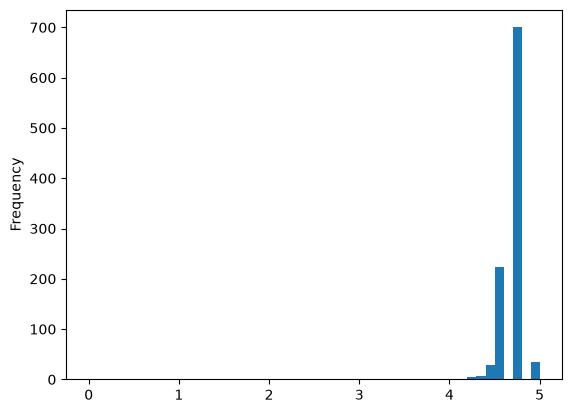

In [32]:
df_sample_1000["average_rating"].plot(kind="hist", bins=50, range=(0, 5))

<Axes: ylabel='Frequency'>

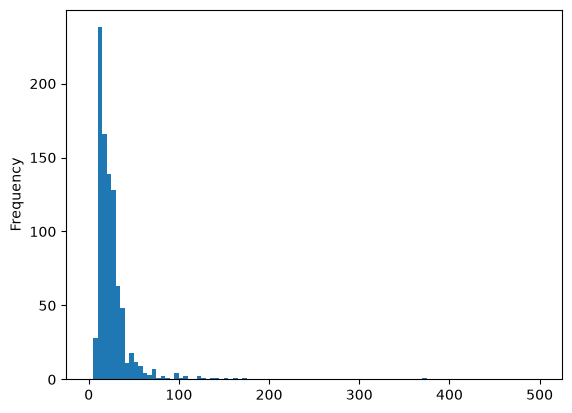

In [33]:
df_sample_1000["price"].plot(kind="hist", bins=100, range=(0, 500))

<Axes: xlabel='main_category'>

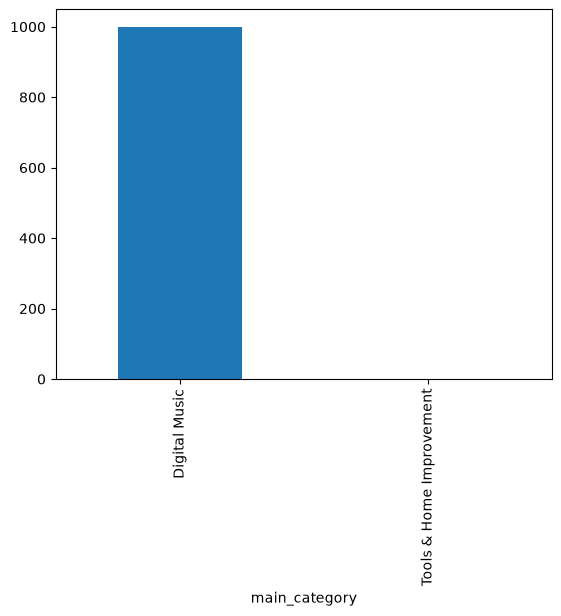

In [34]:
df_sample_1000["main_category"].value_counts().plot(kind="bar")

In [36]:
df_ratings_100.to_json("../../data/meta_CDs_and_Vinyl_2022_2023_with_category_ratings_100.jsonl", orient='records', lines=True)
df_sample_1000.to_json("../../data/meta_CDs_and_Vinyl_2022_2023_with_category_ratings_100_sample_1000.jsonl", orient='records', lines=True)

### Extract ratings that match sampled data

In [37]:
df_ratings_100 = pd.read_json("../../data/meta_CDs_and_Vinyl_2022_2023_with_category_ratings_100.jsonl", lines=True)
df_sample_1000 = pd.read_json("../../data/meta_CDs_and_Vinyl_2022_2023_with_category_ratings_100_sample_1000.jsonl", lines=True)

In [44]:
with gzip.open("../../data/CDs_and_Vinyl.jsonl.gz", 'r') as fp:
    with open("../../data/CDs_and_Vinyl_2022_2023_with_category_ratings_100_sample_1000.jsonl", 'a') as fp_out:
        id_list = set(df_sample_1000['parent_asin'].values)
        i = 0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()
            i += 1
            if i % 100000 == 0:
                print(f"Processed {i} lines")

Processed 100000 lines
Processed 200000 lines
Processed 300000 lines
Processed 400000 lines
Processed 500000 lines
Processed 600000 lines
Processed 700000 lines
Processed 800000 lines
Processed 900000 lines
Processed 1000000 lines
Processed 1100000 lines
Processed 1200000 lines
Processed 1300000 lines
Processed 1400000 lines
Processed 1500000 lines
Processed 1600000 lines
Processed 1700000 lines
Processed 1800000 lines
Processed 1900000 lines
Processed 2000000 lines
Processed 2100000 lines
Processed 2200000 lines
Processed 2300000 lines
Processed 2400000 lines
Processed 2500000 lines
Processed 2600000 lines
Processed 2700000 lines
Processed 2800000 lines
Processed 2900000 lines
Processed 3000000 lines
Processed 3100000 lines
Processed 3200000 lines
Processed 3300000 lines
Processed 3400000 lines
Processed 3500000 lines
Processed 3600000 lines
Processed 3700000 lines
Processed 3800000 lines
Processed 3900000 lines
Processed 4000000 lines
Processed 4100000 lines
Processed 4200000 lines
P